Prototype notebook for the M-z grid script

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import division

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
#matplotlib.rcParams['savefig.dpi'] = 1.5 * matplotlib.rcParams['savefig.dpi']

import os, glob, time, sys, functools
import corner
import numpy as np

import scipy
import scipy.constants as sc
import scipy.integrate as si
import scipy.signal as ssig
import scipy.interpolate as scint
import scipy.linalg as sl

# from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
# import acor

In [3]:
from tqdm import tqdm

In [4]:
import astropy.constants as const
import astropy.coordinates as cc
import astropy.units as u
import astropy_healpix as ahp
from astropy_healpix import healpy as hp
import healpy as hp_old

In [5]:
import PhenomA as pa
import observatories as obs
import WaveformTools as wt
import WaveformTools_old as wto
import utils

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


In [6]:
utils.set_style()

In [7]:
logz_bins = np.loadtxt('./data/Bins_logRedshift.txt')
logM_bins = np.loadtxt('./data/Bins_logMass.txt')
rates = np.loadtxt('./data/d3N_dlogMdlogzdt_LGalaxies.txt')

In [8]:
rates.shape, logz_bins.shape

((77, 175), (78,))

In [9]:
logz_bin_mids = logz_bins[1:] - (logz_bins[1]-logz_bins[0])/2
logM_bin_mids = logM_bins[1:] - (logM_bins[1]-logM_bins[0])/2

In [10]:
logz_bins

array([-2.82385516, -2.77385516, -2.72385516, -2.67385516, -2.62385516,
       -2.57385516, -2.52385516, -2.47385516, -2.42385516, -2.37385516,
       -2.32385516, -2.27385516, -2.22385516, -2.17385516, -2.12385516,
       -2.07385516, -2.02385516, -1.97385516, -1.92385516, -1.87385516,
       -1.82385516, -1.77385516, -1.72385516, -1.67385516, -1.62385516,
       -1.57385516, -1.52385516, -1.47385516, -1.42385516, -1.37385516,
       -1.32385516, -1.27385516, -1.22385516, -1.17385516, -1.12385516,
       -1.07385516, -1.02385516, -0.97385516, -0.92385516, -0.87385516,
       -0.82385516, -0.77385516, -0.72385516, -0.67385516, -0.62385516,
       -0.57385516, -0.52385516, -0.47385516, -0.42385516, -0.37385516,
       -0.32385516, -0.27385516, -0.22385516, -0.17385516, -0.12385516,
       -0.07385516, -0.02385516,  0.02614484,  0.07614484,  0.12614484,
        0.17614484,  0.22614484,  0.27614484,  0.32614484,  0.37614484,
        0.42614484,  0.47614484,  0.52614484,  0.57614484,  0.62

/tmp/ipykernel_13116/3671508646.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(logM_bin_mids,10**logz_bin_mids,np.log10(rates),cmap='cool',levels=np.linspace(-3,0,7))


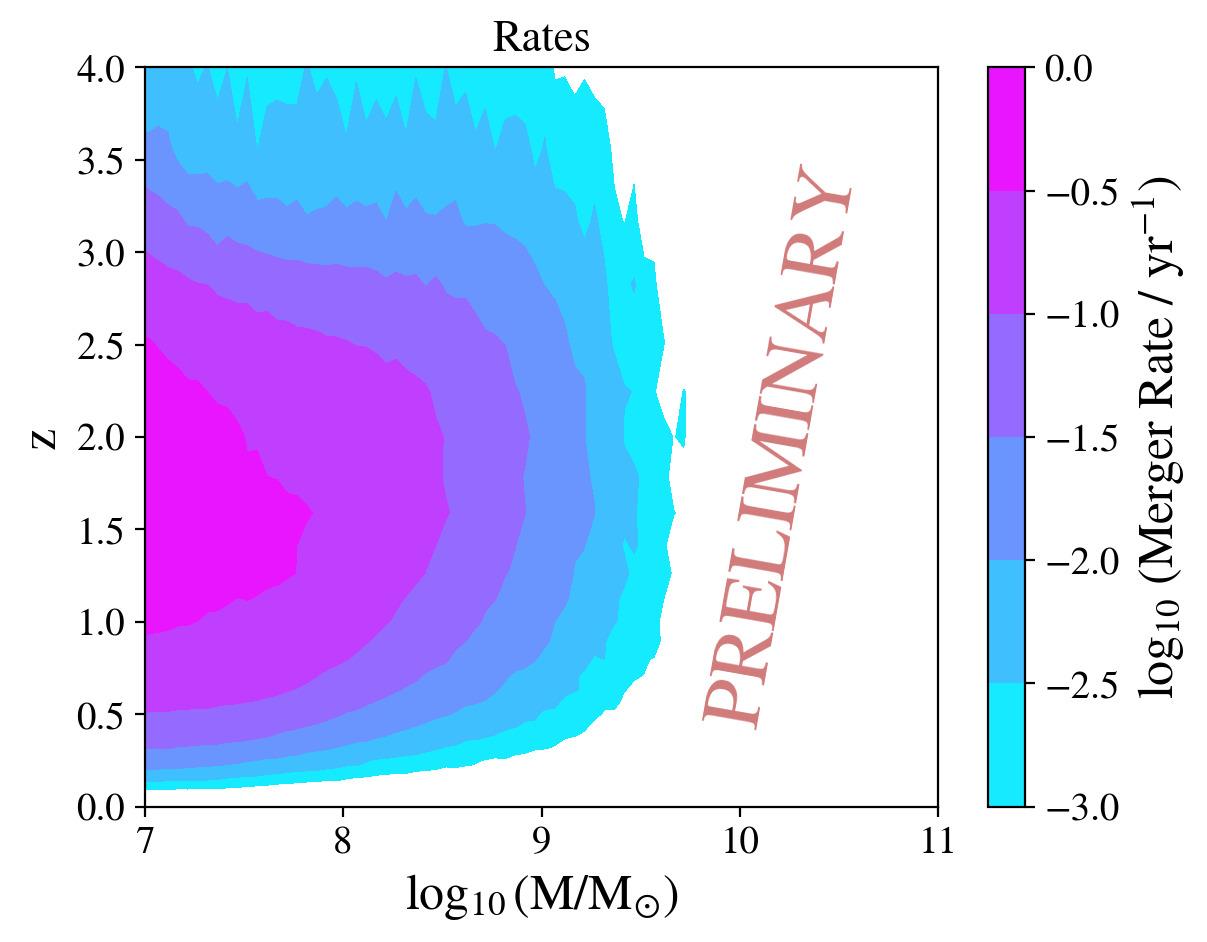

In [11]:
plt.figure()
plt.contourf(logM_bin_mids,10**logz_bin_mids,np.log10(rates),cmap='cool',levels=np.linspace(-3,0,7))
cbar = plt.colorbar()
cbar.ax.set_ylabel('log$_{10}$ (Merger Rate / yr$^{-1})$',fontsize=18)
plt.xlabel(r'$\log_{10}(\mathrm{M/M_{\odot}})$',fontsize=18)
plt.ylabel('z',fontsize=18)
plt.ylim(0,4)
plt.xlim(7,11)
plt.title("Rates")
plt.text(9.8,0.5,"PRELIMINARY",fontsize=30,color='firebrick',alpha=0.6,rotation=80)
plt.show()

In [12]:
np.sum(rates*(logz_bins[1:]-logz_bins[:-1])[:,None],axis=0)

array([5.86652004e-07, 1.61053003e-07, 2.21728605e-06, 6.32574033e-06,
       1.56102064e-05, 5.30090729e-05, 1.59156137e-04, 1.50168665e-04,
       4.34337677e-04, 6.19075276e-04, 1.28015837e-03, 2.00321924e-03,
       3.26638654e-03, 4.79763743e-03, 5.94518587e-03, 8.15685654e-03,
       1.15579517e-02, 1.61151674e-02, 2.48565596e-02, 2.36212456e-02,
       5.41004370e-02, 1.17705059e-01, 1.11589639e-01, 1.31957181e-01,
       2.13469433e-01, 2.07946186e-01, 3.39366793e-01, 4.85759645e-01,
       5.00103414e-01, 4.52110057e-01, 6.18211725e-01, 6.79412392e-01,
       5.21054165e-01, 7.17737636e-01, 9.64715821e-01, 8.33982574e-01,
       9.90032509e-01, 8.39770216e-01, 7.23523965e-01, 5.98984060e-01,
       7.34190726e-01, 7.33197987e-01, 6.93910122e-01, 6.99017709e-01,
       6.81198279e-01, 7.26254345e-01, 7.87086969e-01, 6.78635547e-01,
       7.80993549e-01, 8.38164218e-01, 7.98309879e-01, 7.32101618e-01,
       7.81707898e-01, 8.70114918e-01, 9.62884803e-01, 9.52290453e-01,
      

In [13]:
rates_zint = np.sum(rates*(logz_bins[1:]-logz_bins[:-1])[:,None],axis=0)

/tmp/ipykernel_13116/3927082606.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(logM_bin_mids,np.log10(rates_zint))


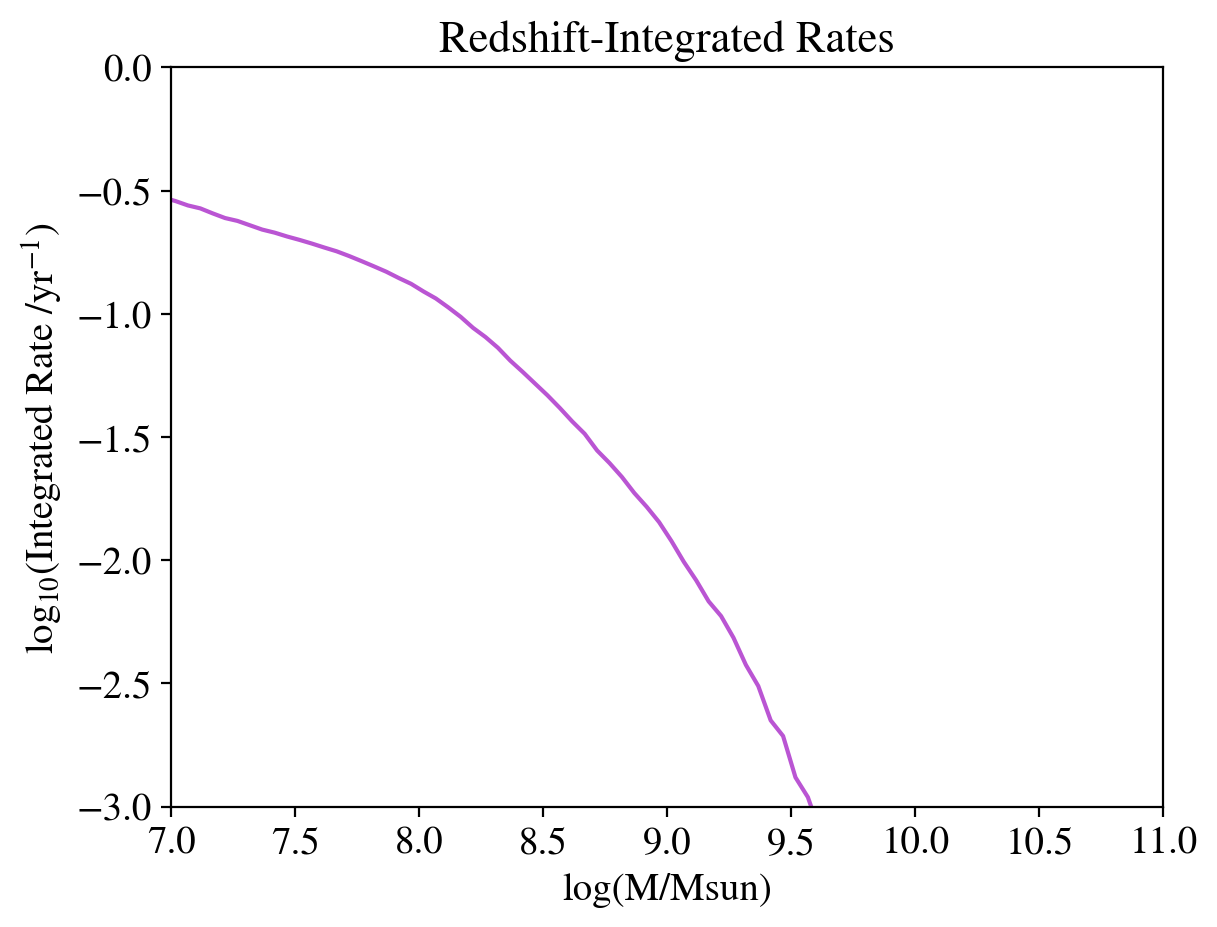

In [14]:
plt.figure()
plt.plot(logM_bin_mids,np.log10(rates_zint))
# plt.contourf(logM_bin_mids,10**logz_bin_mids,np.log10(rates),cmap='cool',levels=np.linspace(-2,1,10))
# plt.colorbar(label='log$_{10}$ (rate /yr$^{-1})$')
plt.xlabel('log(M/Msun)')
plt.ylabel('log$_{10}$(Integrated Rate /yr$^{-1}$)')
plt.ylim(-3,0)
plt.xlim(7,11)
plt.title("Redshift-Integrated Rates")
plt.show()

In [15]:
logM_bins[1] - logM_bins[0]

0.050000000000000044

In [16]:
gtr1e9 = logM_bin_mids>9.0
rates_fullint = np.sum(rates_zint[gtr1e9]*(logM_bins[1:] - logM_bins[:-1])[gtr1e9])

In [17]:
print(rates_fullint)

0.003189766799400277


In [18]:
## integrated rates, cumulative descending
ircd = np.cumsum((rates_zint*(logM_bins[1:] - logM_bins[:-1]))[::-1])

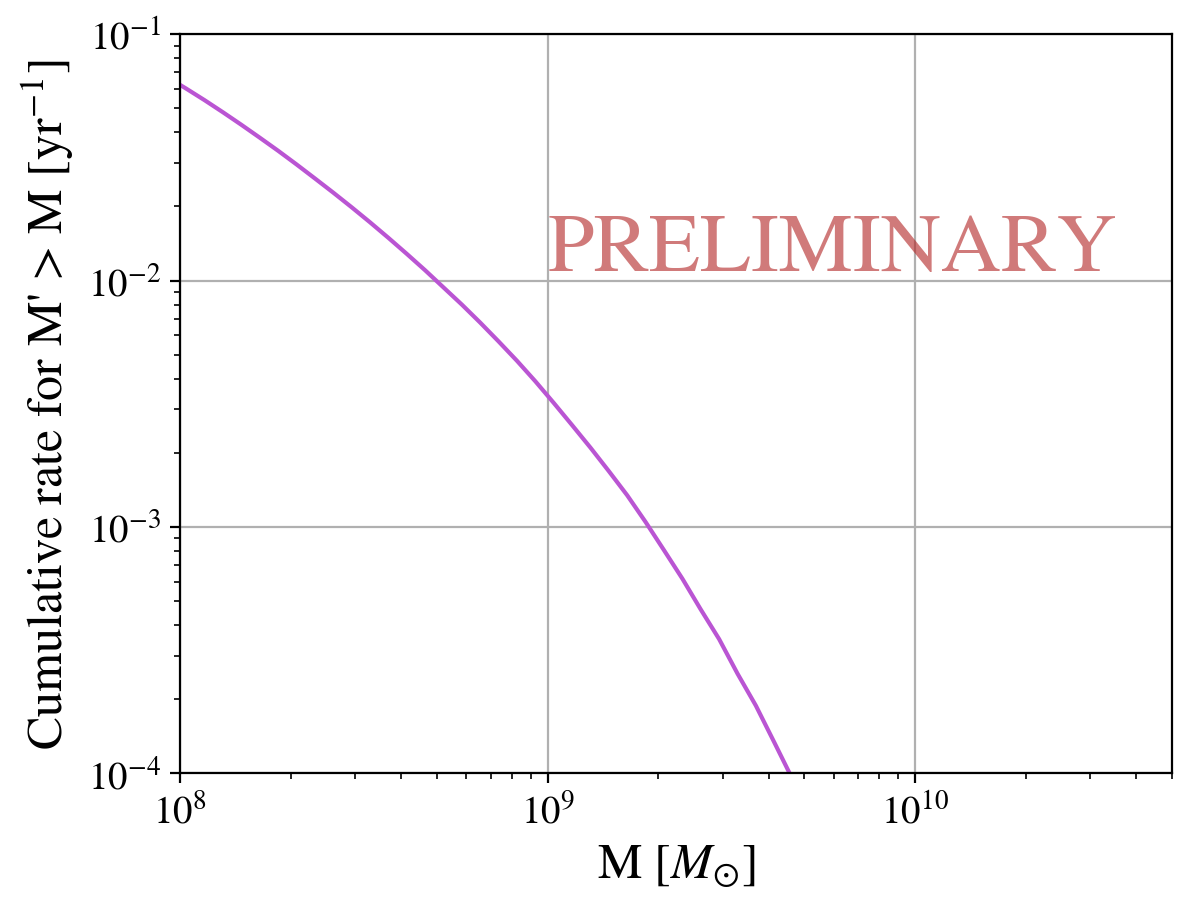

In [19]:
plt.figure()
plt.loglog(10**logM_bin_mids[::-1],ircd)
plt.xlabel(r'M [$M_{\odot}$]',fontsize=18)
plt.ylabel("Cumulative rate for M' > M [yr$^{-1}$]",fontsize=18)
plt.ylim(1e-4,1e-1)
plt.xlim(1e8,5e10)
plt.grid()
plt.text(1e9,0.011,"PRELIMINARY",fontsize=30,color='firebrick',alpha=0.6)
plt.show()

In [20]:
10**8.75,1/10**-1.75

(562341325.1903491, 56.2341325190349)

In [21]:
muAres_snfile = 'strain_sens_ARES_instrument.txt'

In [22]:
muAres = obs.Observatory("muAres",4*u.yr,sens_curve=muAres_snfile)

In [23]:
lisa = obs.LISA() 

In [24]:
kepler = obs.Astrometry("Kepler")

In [25]:
roman = obs.Astrometry("Roman")

In [26]:
dr3like = obs.EchoArray(nside=16)

Loading Enterprise pulsars...
PSR B1855+09 complete  [tempo2Util.C:396] Warning: [MISC1] Unknown parameter in par file:  DMDATA
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.
[tempo2Util.C:396] Warning: [PAR2] Have not set a DM epoch. The period epoch will be used instead. B1855+09.par
PSR J2322-2650 complete   
Timespan: 22.2 yrs

Computing correlations...
PSR J2322-2650 complete   
Creating hasasia spectra...
PSR J2322-2650 complete   

In [32]:
len(dr3like.psrs)

116

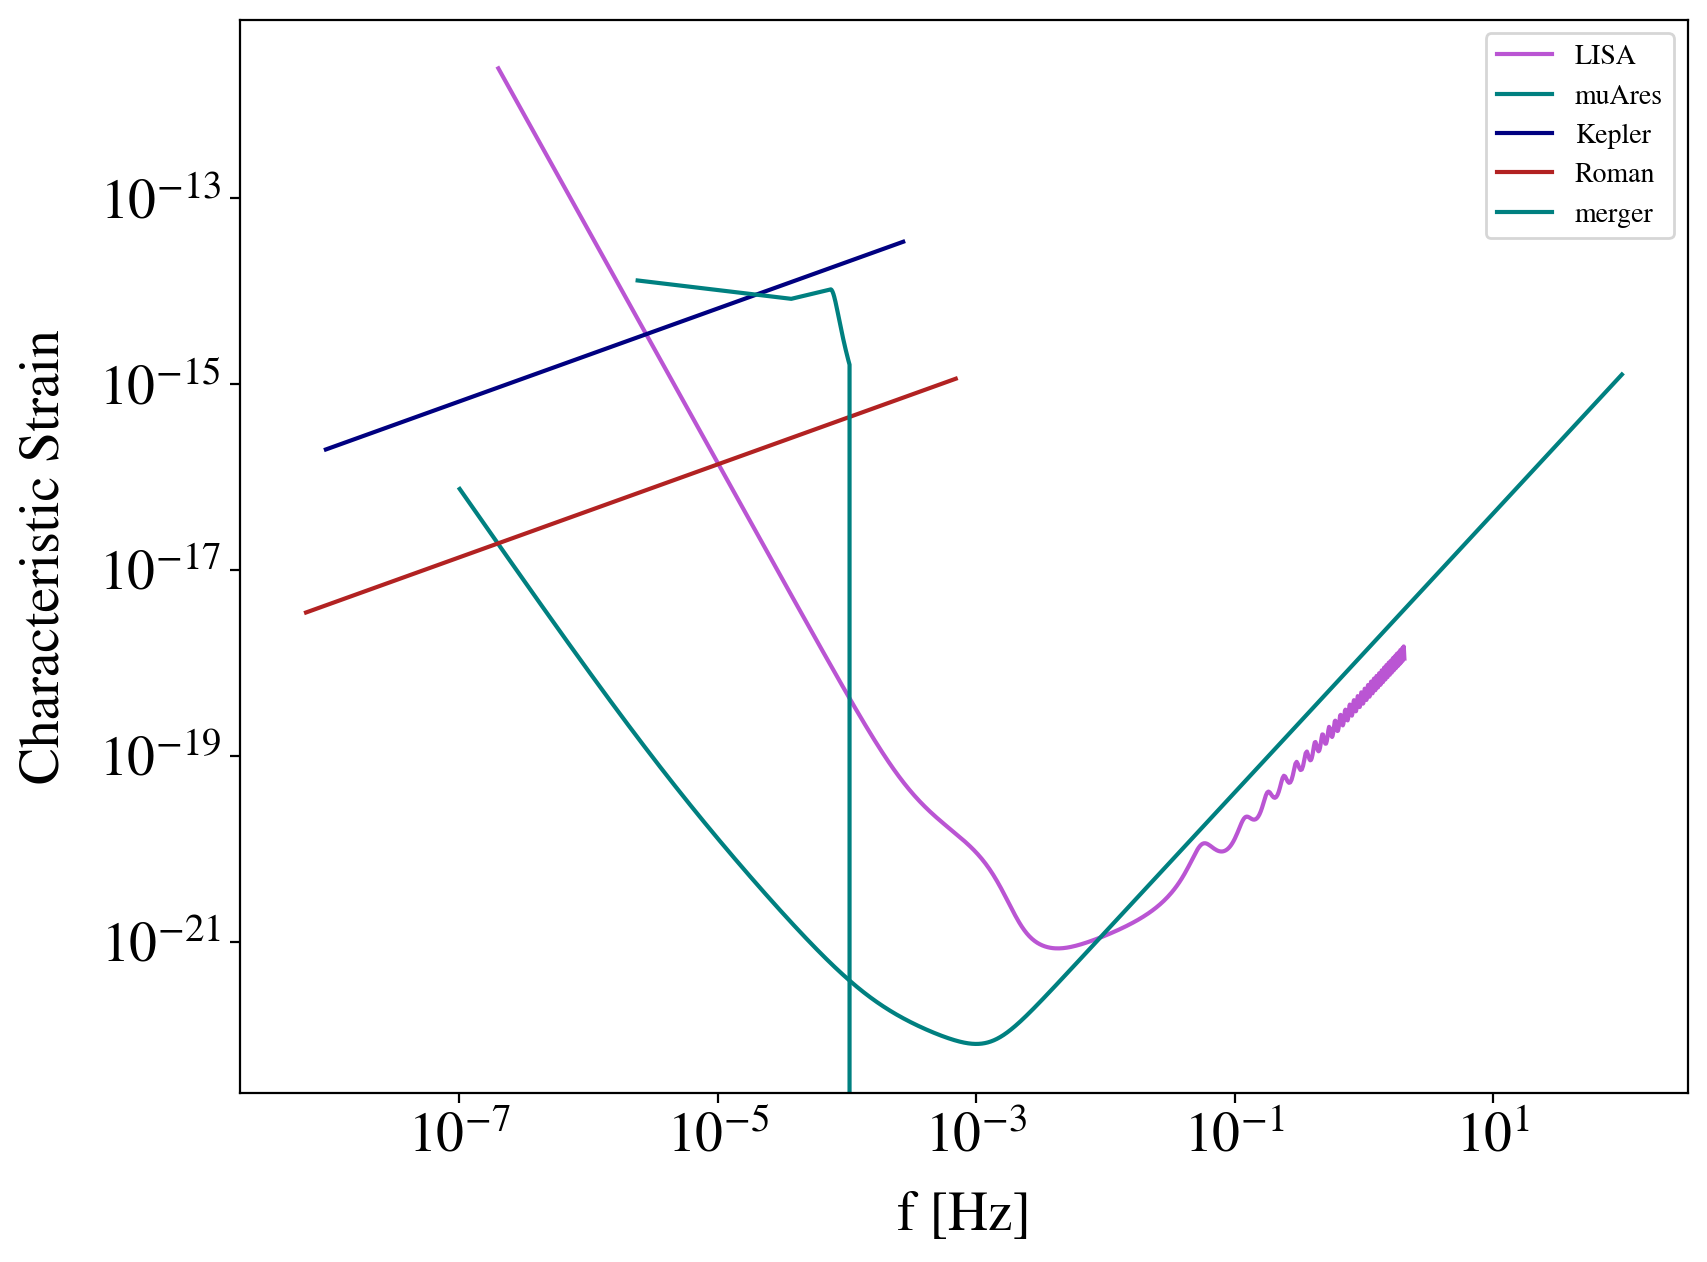

In [240]:
ax = obs.plot_multi_obs_sensitivity([lisa,muAres,kepler,roman],show=False)
binary = wt.Binary(1e8,1e8,z=0.1)
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)
binary.SetFreqBounds(muAres)
freqs, hc = binary.CalcStrain(muAres)
binary.add_strain_to_plot(ax, freqs, hc,color='teal',label='merger')
plt.legend()
plt.show()

In [233]:
roman.Sn(1e-8)

array([1.86877115e-27])

In [234]:
roman.base_fs

array([6.33761756e-09, 1.39799715e-06, 2.78965668e-06, 4.18131622e-06,
       5.57297575e-06, 6.96463528e-06, 8.35629481e-06, 9.74795435e-06,
       1.11396139e-05, 1.25312734e-05, 1.39229329e-05, 1.53145925e-05,
       1.67062520e-05, 1.80979115e-05, 1.94895711e-05, 2.08812306e-05,
       2.22728901e-05, 2.36645497e-05, 2.50562092e-05, 2.64478687e-05,
       2.78395283e-05, 2.92311878e-05, 3.06228473e-05, 3.20145069e-05,
       3.34061664e-05, 3.47978259e-05, 3.61894855e-05, 3.75811450e-05,
       3.89728045e-05, 4.03644641e-05, 4.17561236e-05, 4.31477831e-05,
       4.45394427e-05, 4.59311022e-05, 4.73227617e-05, 4.87144213e-05,
       5.01060808e-05, 5.14977403e-05, 5.28893999e-05, 5.42810594e-05,
       5.56727189e-05, 5.70643785e-05, 5.84560380e-05, 5.98476975e-05,
       6.12393571e-05, 6.26310166e-05, 6.40226761e-05, 6.54143357e-05,
       6.68059952e-05, 6.81976547e-05, 6.95893143e-05, 7.09809738e-05,
       7.23726333e-05, 7.37642929e-05, 7.51559524e-05, 7.65476119e-05,
      

In [110]:
wt.Binary(1e8,1e8,z=2,verbose=True)

Redshift provided. 
	Luminosity Distance........... 15817.334433708149 Mpc


In [90]:
## get multiband SNRs for a random binary
baseHP = ahp.HEALPix(16,frame='barycentricmeanecliptic')
sky_loc = baseHP.healpix_to_skycoord(850) ## random sky loc, will do average over sky later
## assuming equal mass ratios for now
Nm = 100
Nz = 100
T_merge = 1*obs.YEAR
Mtots = np.logspace(7,11,Nm)
zs = np.linspace(0.01,8,Nz)
snrs = {name:np.empty((Nm,Nz)) for name in [lisa.name,muAres.name,kepler.survey,roman.survey,'echo']}
for i in tqdm(range(len(Mtots))):
    for j in range(len(zs)):
        # m1 = m2 = Mtots[i]/2
        m1 = 0.5*Mtots[i].copy()
        m2 = 0.5*Mtots[i].copy()
        z = zs[j]
        for obs_i in [lisa,muAres,kepler,roman]:
            binary_i = wt.Binary(m1,m2,z=z,sky_loc=sky_loc)
            if obs_i.name == 'astrometry':
                name_i = obs_i.survey
            else:
                name_i = obs_i.name
            snrs[name_i][i,j] = binary_i.run_full_SNR_calc(obs_i,T_merge)
            snrs['echo'][i,j] = np.sqrt(dr3like.calc_echo_snr(binary_i))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:00:41<00:00, 36.41s/it]


In [223]:
merger_snr_min = 50

SNR parameter-space "maps":

In [224]:
any_cond = np.any([snrs[name]>merger_snr_min for name in [lisa.name,muAres.name,kepler.survey,roman.survey]],axis=0)

In [225]:
any_arr = np.ma.array(np.log10(snrs['echo']),mask=np.invert(any_cond),fill_value=np.nan)
single_arrs = []
names = [lisa.name,muAres.name,kepler.survey,roman.survey]
for name in names:
    cond_i = snrs[name]>merger_snr_min
    single_arrs.append(np.ma.array(np.log10(snrs['echo']),mask=np.invert(cond_i),fill_value=np.nan))

In [217]:
# Mgrid, zgrid = np.meshgrid(Mtots,zs)
# plt.figure()
# plt.xscale('log')
# plt.contourf(Mgrid.T,zgrid.T,any_arr,cmap='cool',vmin=-1,levels=[-1,0,1,2,3,4,5],extend='both')
# legend_elements = [Patch(facecolor='white', edgecolor='k',label='Merger SNR <{}'.format(merger_snr_min))]
# plt.legend(handles=legend_elements, loc='upper right')
# plt.xlabel('Total Mass [Msun]')
# plt.ylabel('Redshift')
# # plt.legend(bbox_to_anchor=(1,1))
# plt.colorbar(label='log10 Echo SNR')
# plt.title("Any Combination")
# plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs/Mz_SNR_Any.png',dpi=200)
# plt.show()

In [226]:
def set_style():
    plt.style.use('default')
    default_cycler=plt.cycler(color=['mediumorchid','teal','navy','firebrick','goldenrod','slategrey'])
    plt.rc('axes', prop_cycle=default_cycler)
    
    ## TODO -- add some font size/style, etc. here
    plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
    
    plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    
    return

In [227]:
set_style()

In [220]:
# import matplotlib.font_manager; [font for font in matplotlib.font_manager.get_font_names() if 'Noto' not in font]

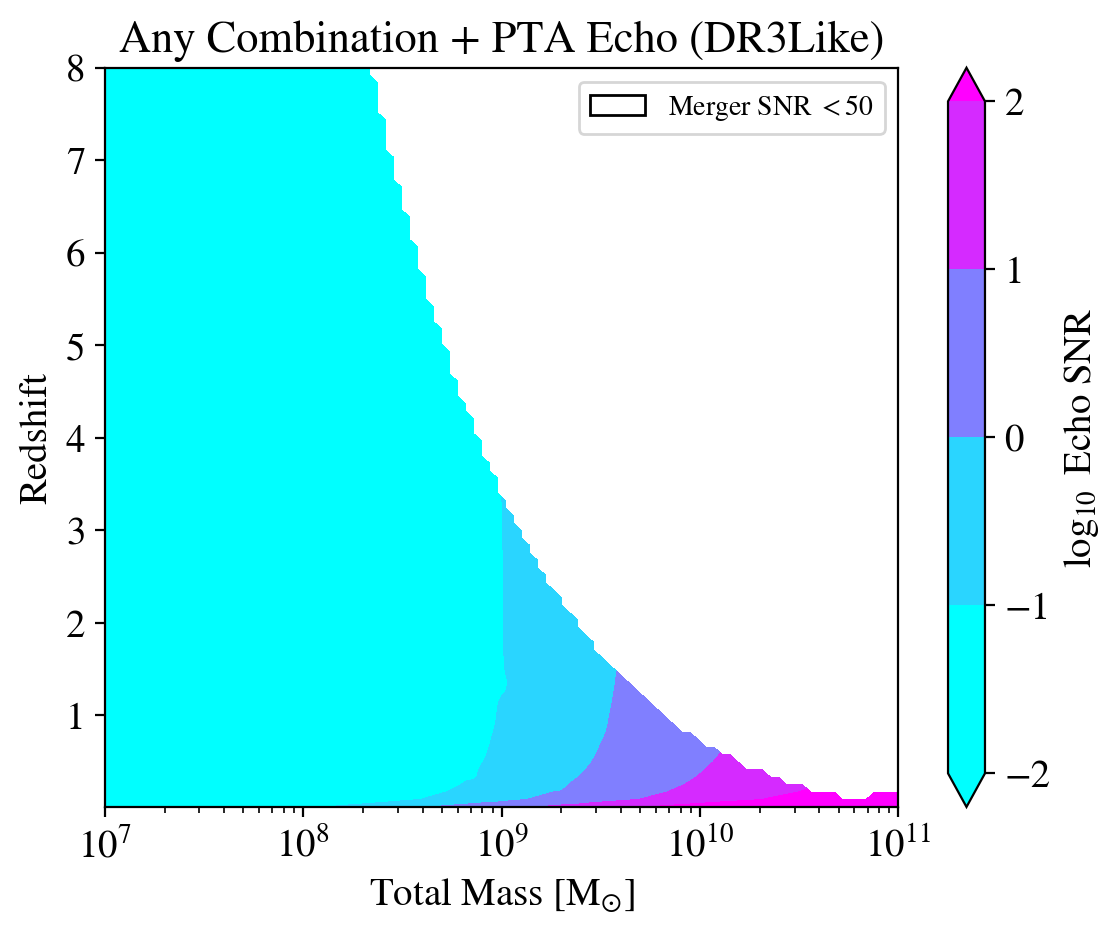

In [228]:
Mgrid, zgrid = np.meshgrid(Mtots,zs)
plt.figure()
plt.xscale('log')
plt.contourf(Mgrid.T,zgrid.T,any_arr,cmap='cool',vmin=-1,levels=[-2,-1,0,1,2],extend='both')
legend_elements = [Patch(facecolor='white', edgecolor='k',label='Merger SNR $<{}$'.format(merger_snr_min))]
plt.legend(handles=legend_elements, loc='upper right')
plt.xlabel(r'Total Mass [$\mathrm{M_{\odot}}$]')
plt.ylabel('Redshift')
# plt.legend(bbox_to_anchor=(1,1))
plt.colorbar(label=r'$\log_{10}$ Echo SNR')
plt.title("Any Combination + PTA Echo (DR3Like)")
plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs/Mz_SNR_Any.png',dpi=200)
plt.show()

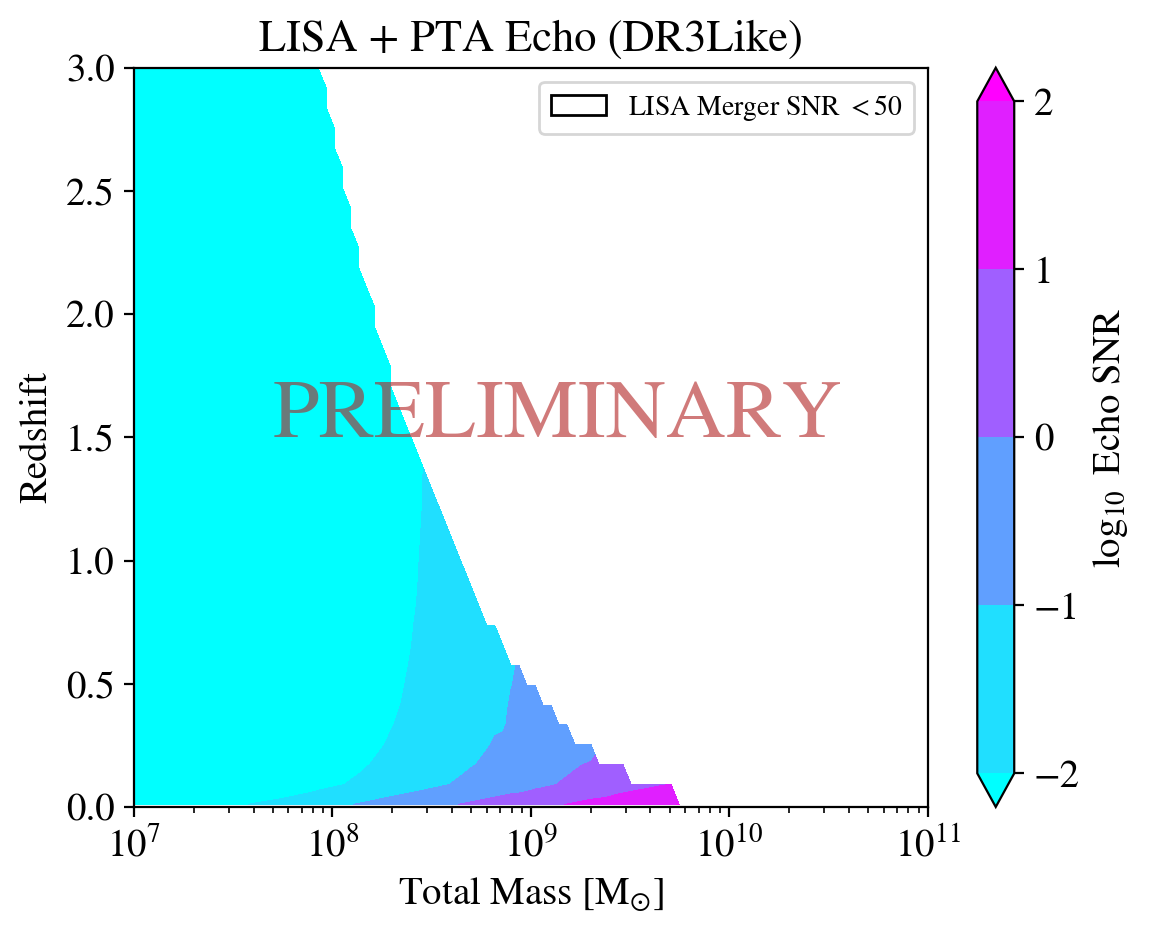

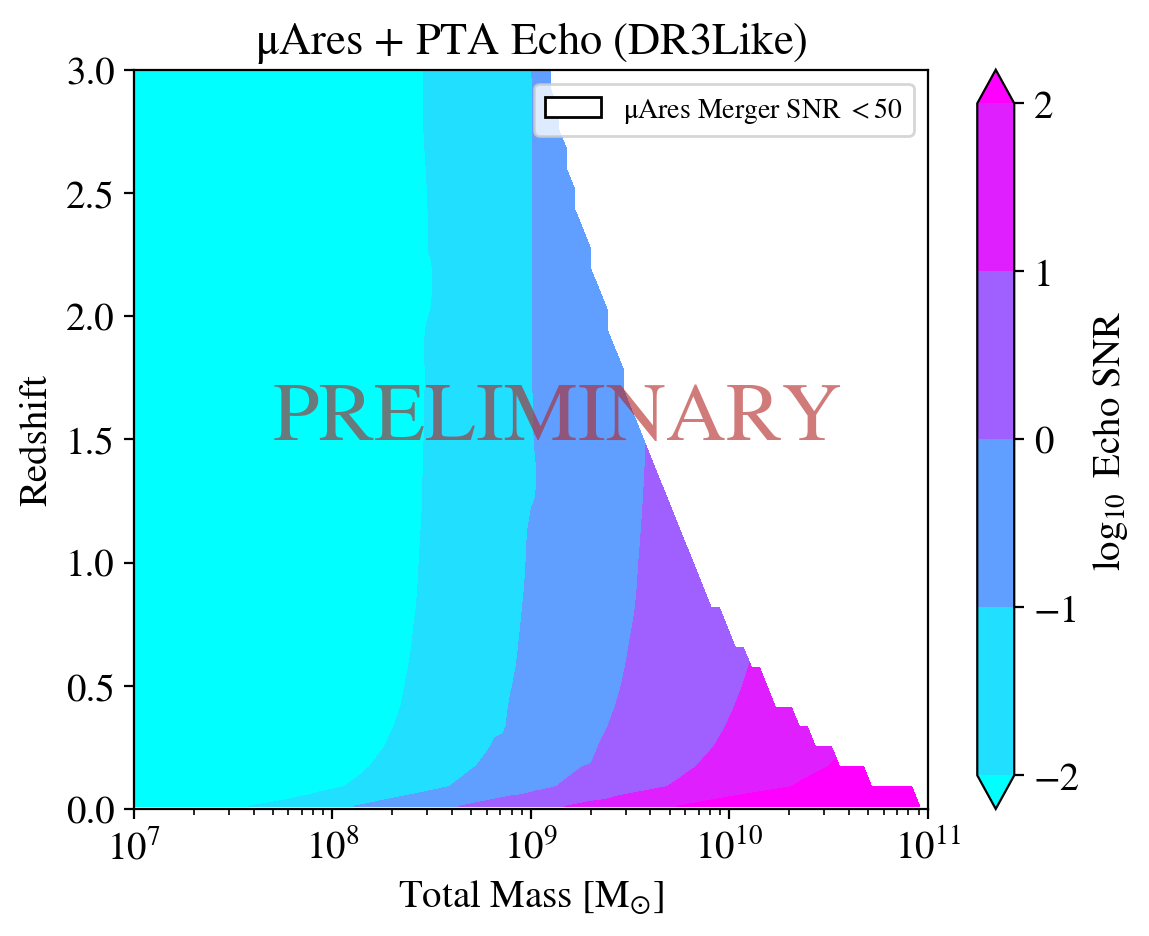

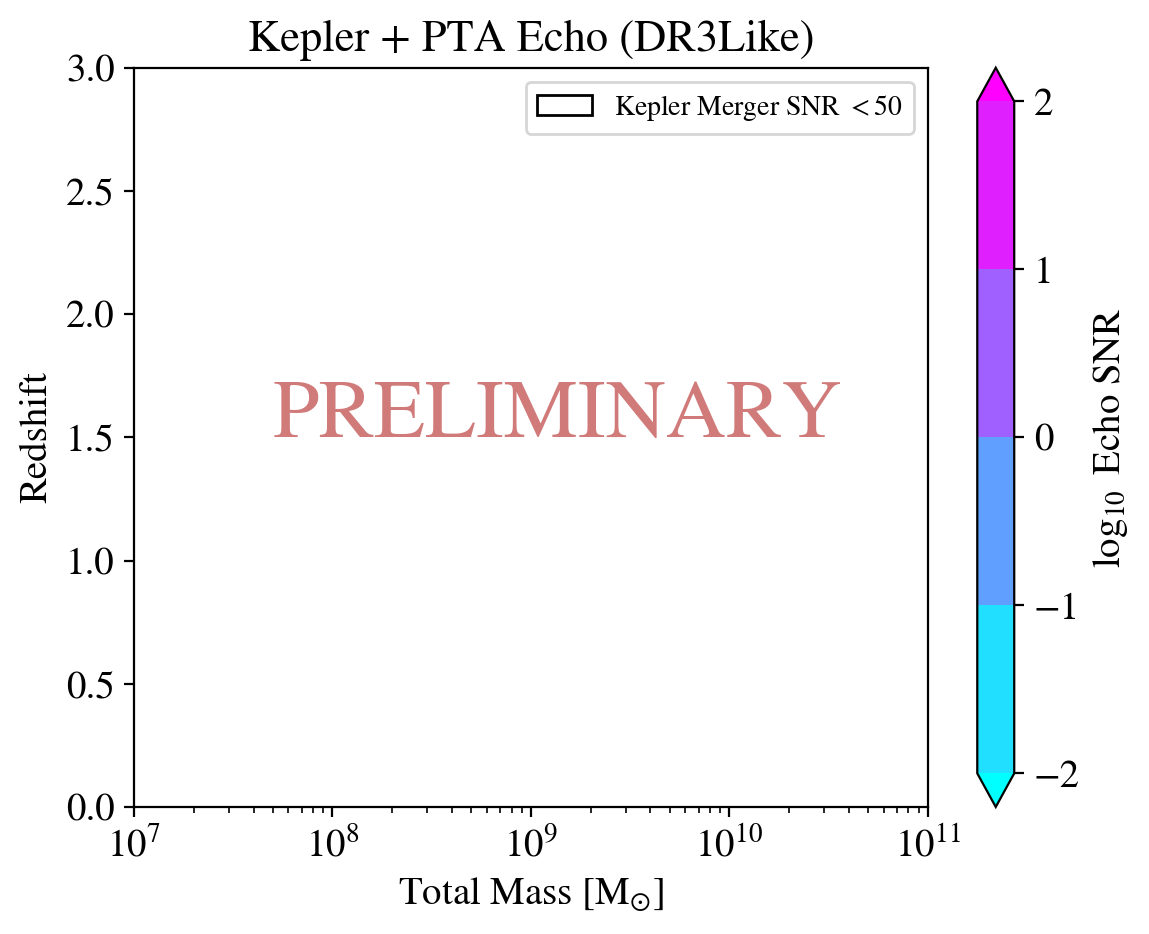

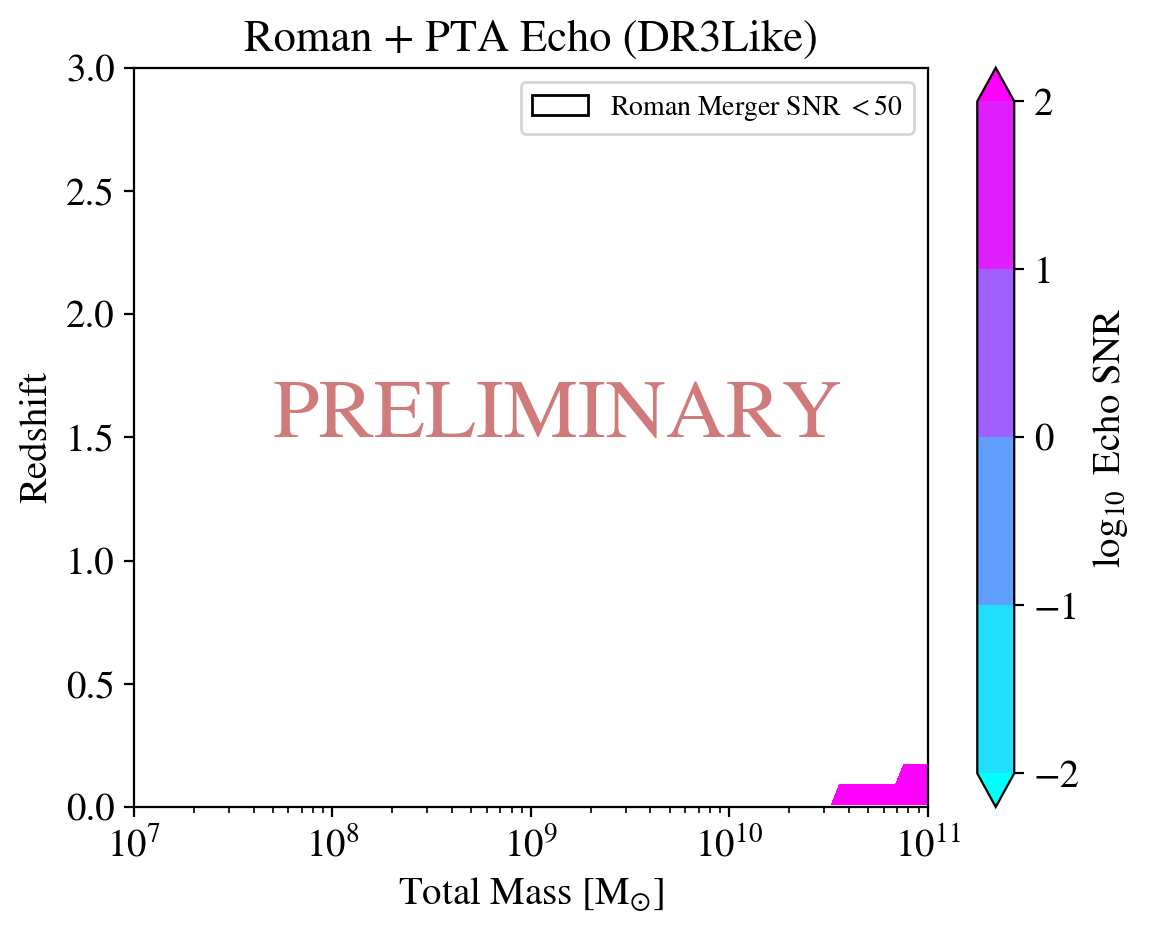

In [229]:
for i in range(len(names)):
    name_i = names[i]
    if names[i]=='muAres':
        name_i = r'$\mathrm{\mu}$Ares'
    plt.figure()
    plt.xscale('log')
    plt.contourf(Mgrid.T,zgrid.T,single_arrs[i],cmap='cool',levels=[-2,-1,0,1,2],extend='both')
    legend_elements = [Patch(facecolor='white', edgecolor='k',label='{} Merger SNR $<{}$'.format(name_i,merger_snr_min))]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.xlabel(r'Total Mass [$\mathrm{M_{\odot}}$]')
    plt.ylabel('Redshift')
    plt.ylim(0,3)
    plt.colorbar(label=r'$\log_{10}$ Echo SNR')
    plt.title("{} + PTA Echo (DR3Like)".format(name_i))
    plt.text(5e7,1.5,"PRELIMINARY",fontsize=30,color='firebrick',alpha=0.6)
    # plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs_lowz_msnr10/Mz_SNR_{}.png'.format(names[i]),
    #             dpi=200)
    plt.show()

/tmp/ipykernel_401314/2420621287.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(Mgrid.T,zgrid.T,np.log10(snrs[names[i]]),cmap='cool',levels=[-1,0,1,2,3],extend='both')


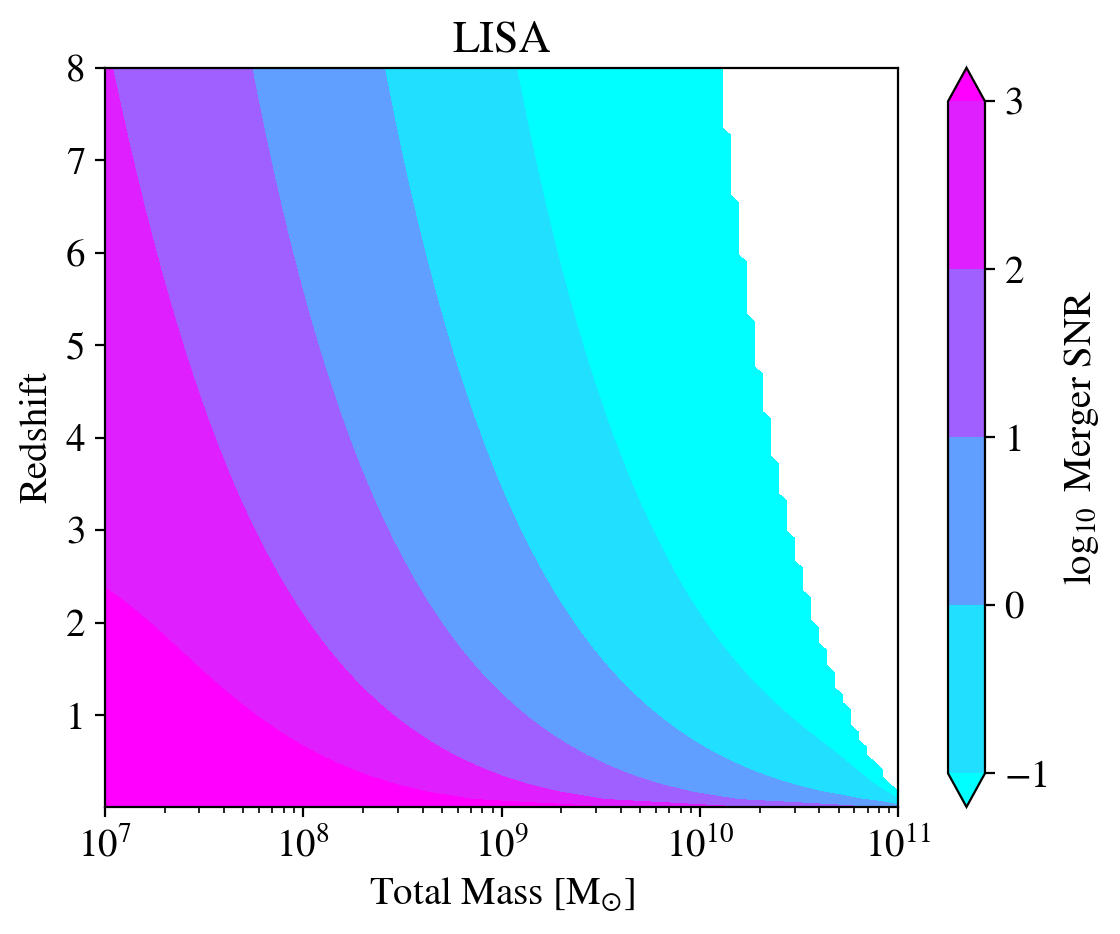

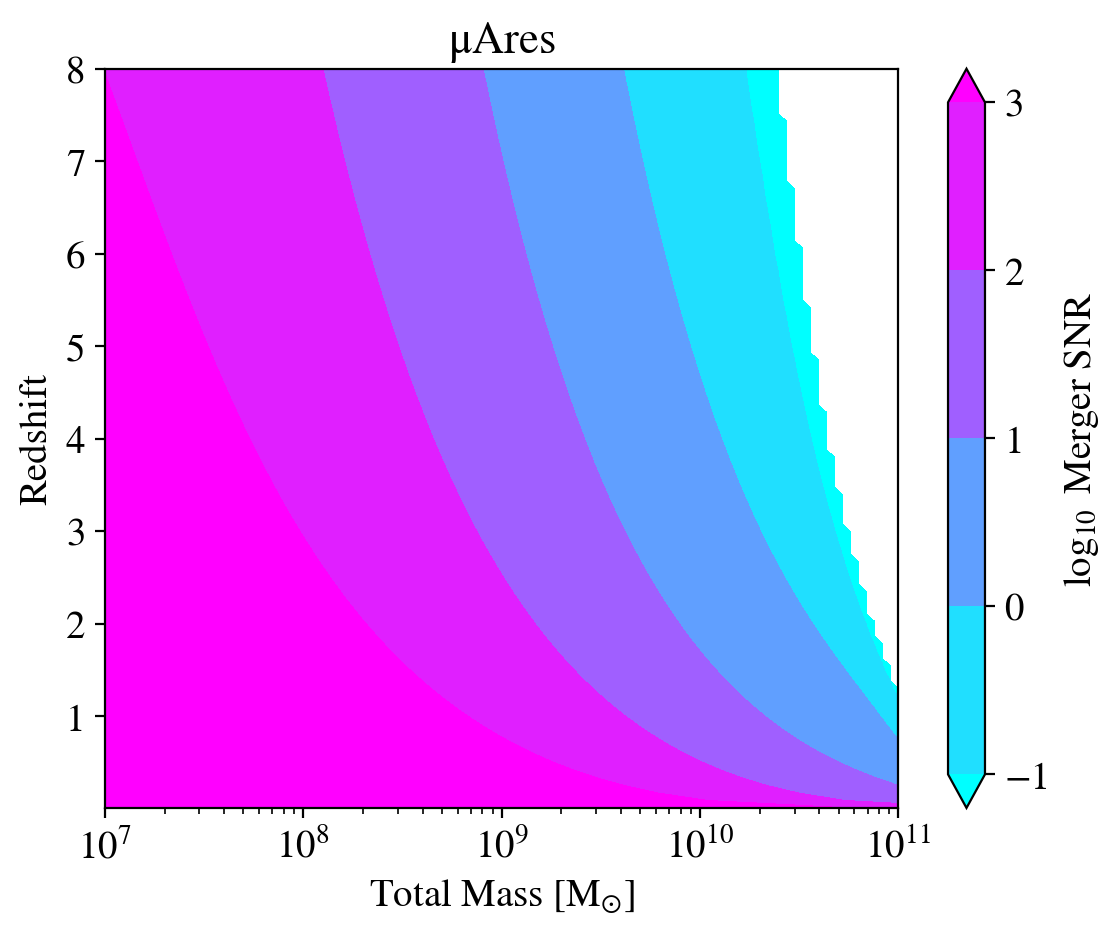

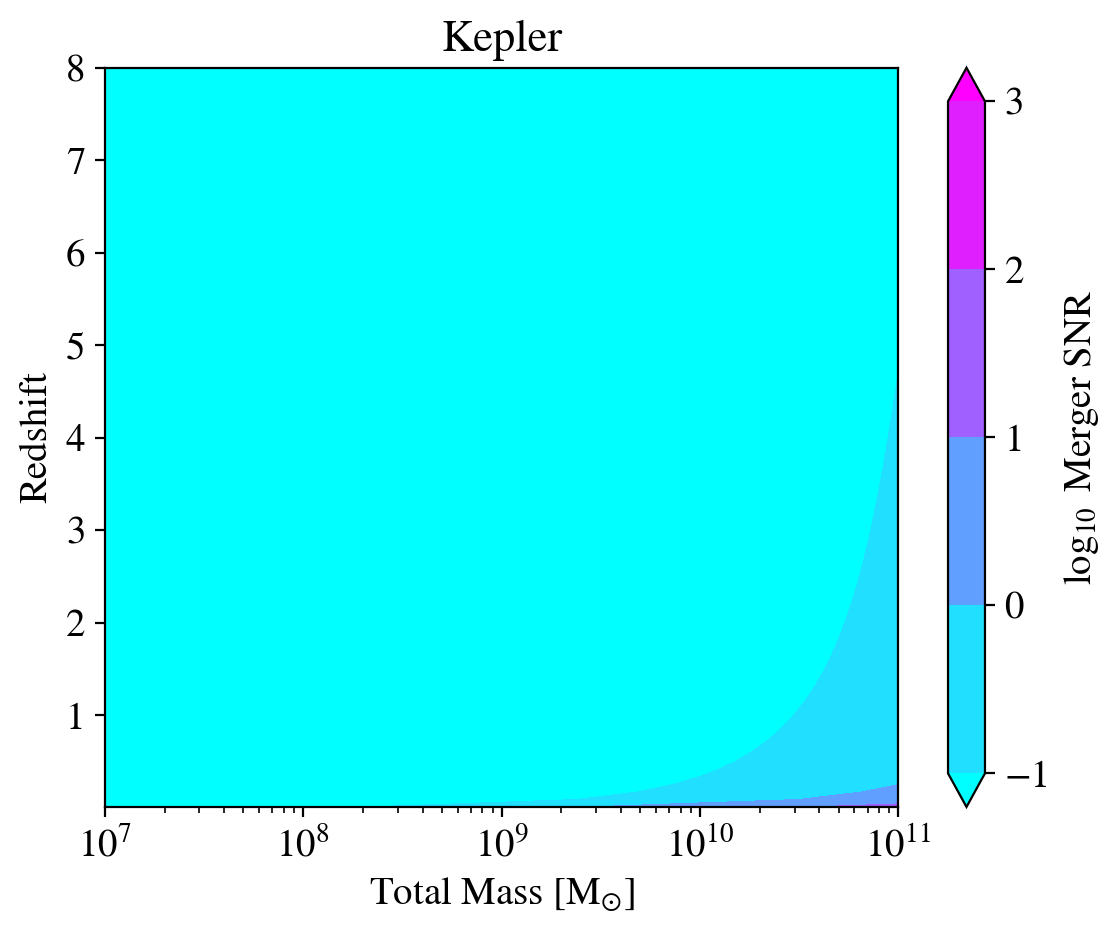

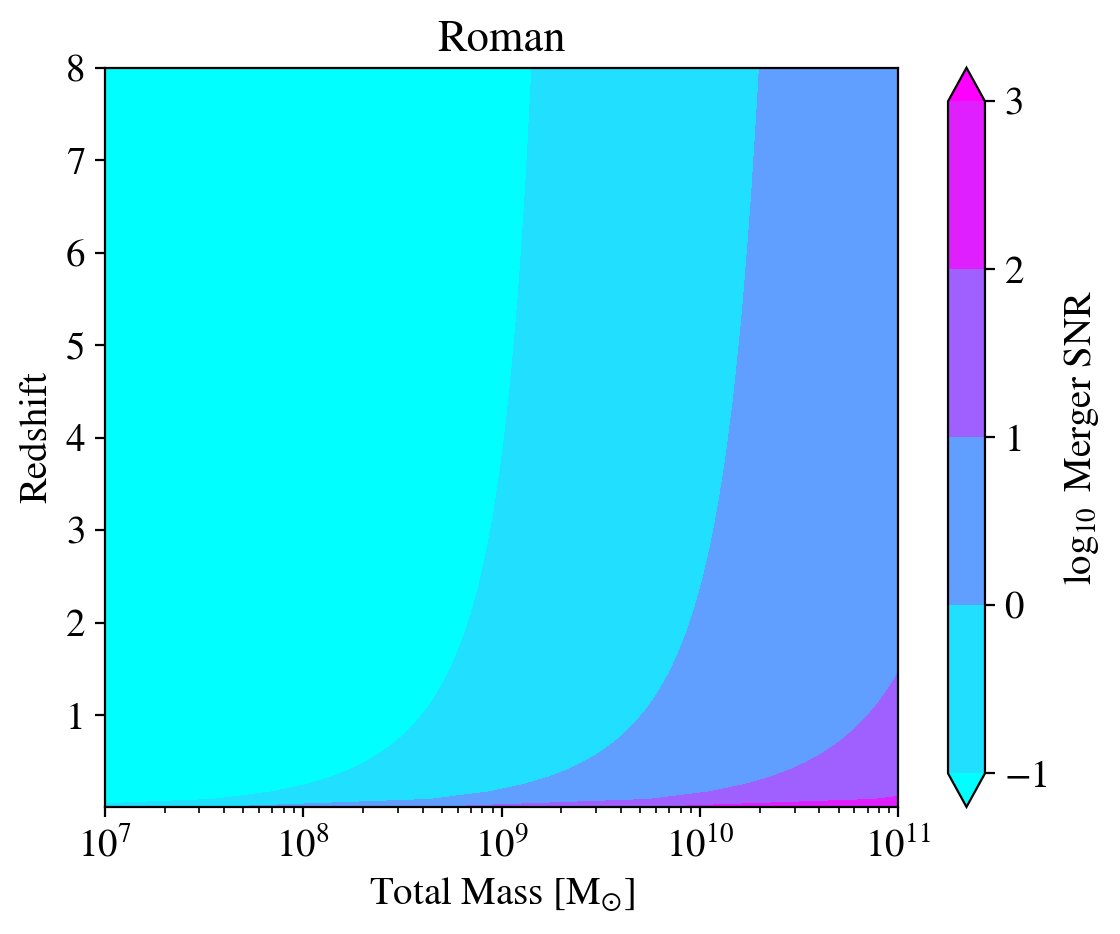

In [193]:
## check merger SNR maps
for i in range(len(names)):
    plt.figure()
    plt.xscale('log')
    plt.contourf(Mgrid.T,zgrid.T,np.log10(snrs[names[i]]),cmap='cool',levels=[-1,0,1,2,3],extend='both')
    plt.xlabel(r'Total Mass [$\mathrm{M_{\odot}}$]')
    plt.ylabel('Redshift')
    plt.colorbar(label=r'$\log_{10}$ Merger SNR')
    name_i = names[i]
    if names[i]=='muAres':
        name_i = r'$\mathrm{\mu}$Ares'
    plt.title("{}".format(name_i))
    plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs/Mz_merger_SNR_{}.png'.format(names[i]),
                dpi=200)
    plt.show()

Yes/no plots

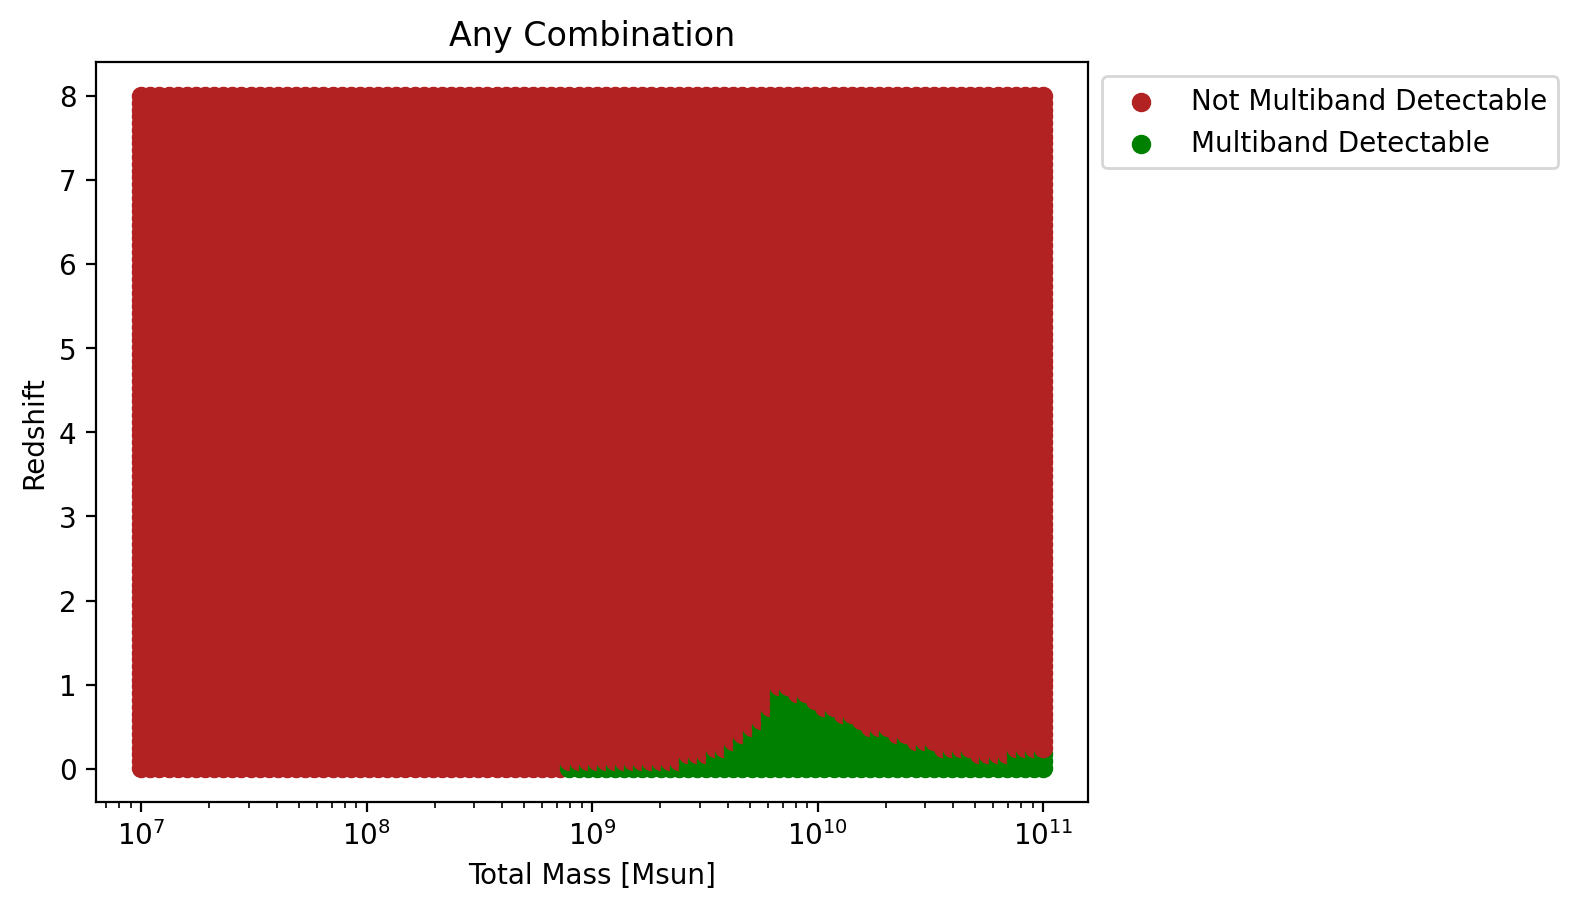

In [121]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [lisa.name,muAres.name,kepler.survey,roman.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Any Combination")
plt.show()

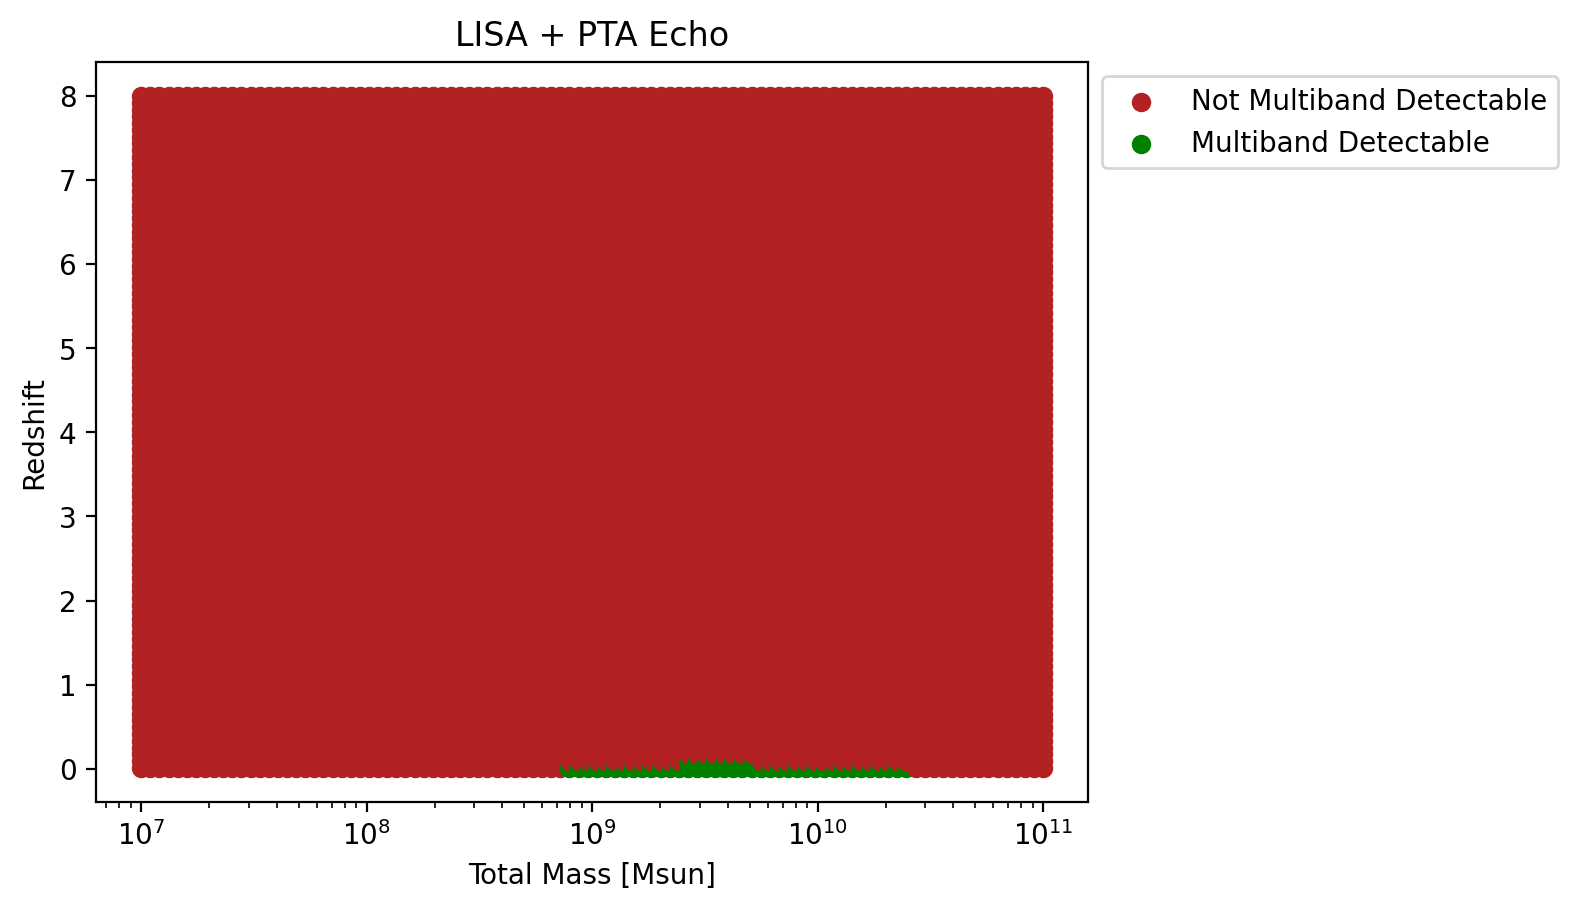

In [122]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [lisa.name]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("LISA + PTA Echo")
plt.show()

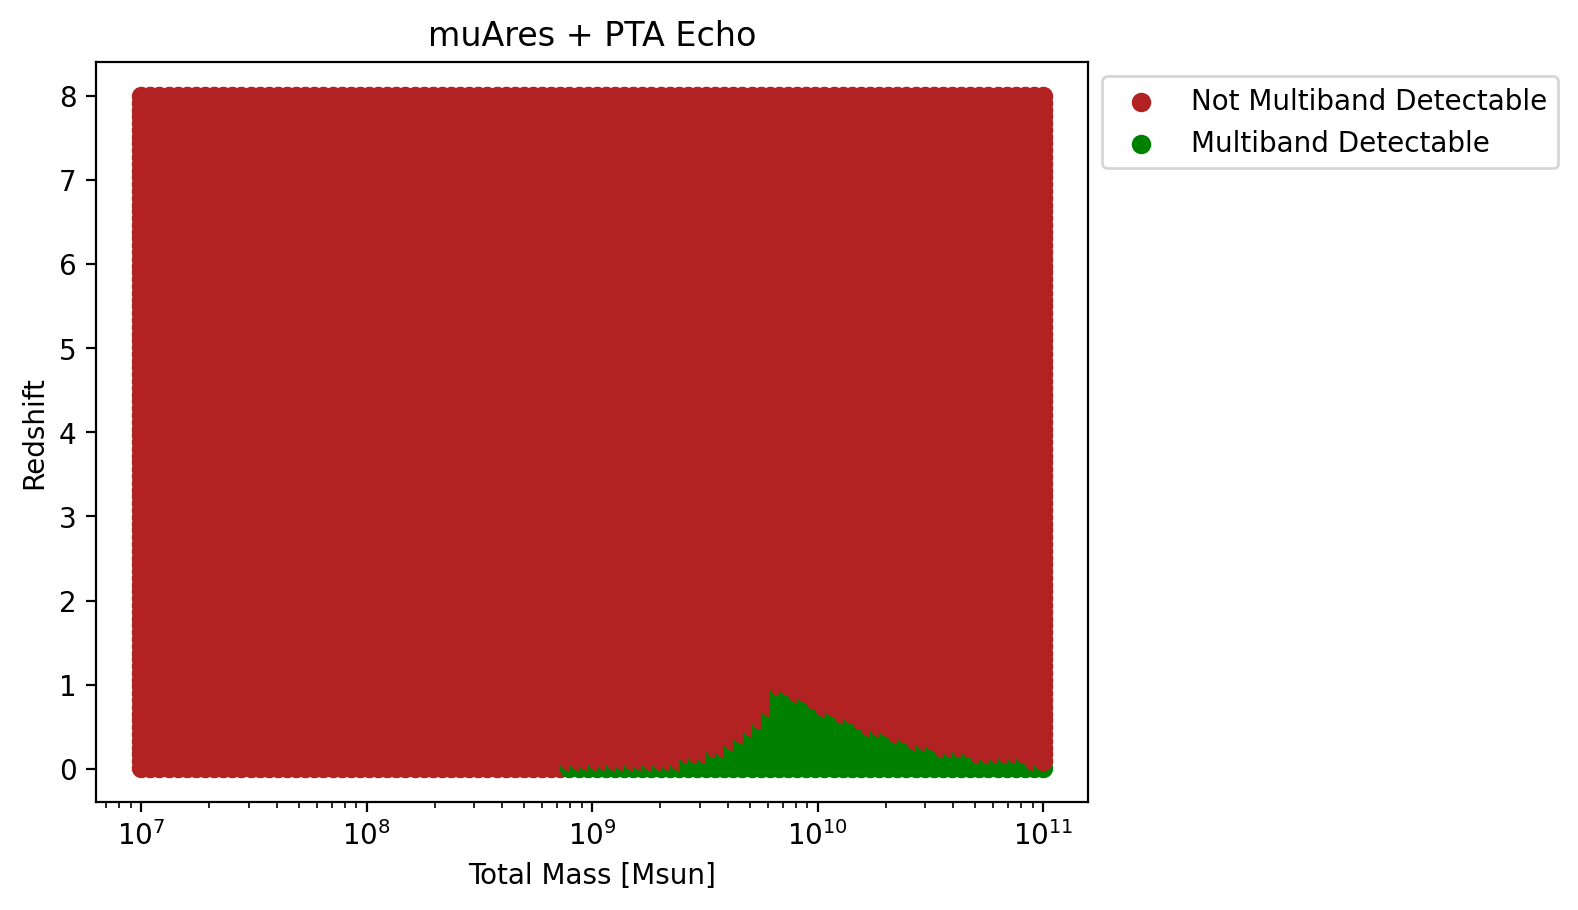

In [123]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [muAres.name]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("muAres + PTA Echo")
plt.show()

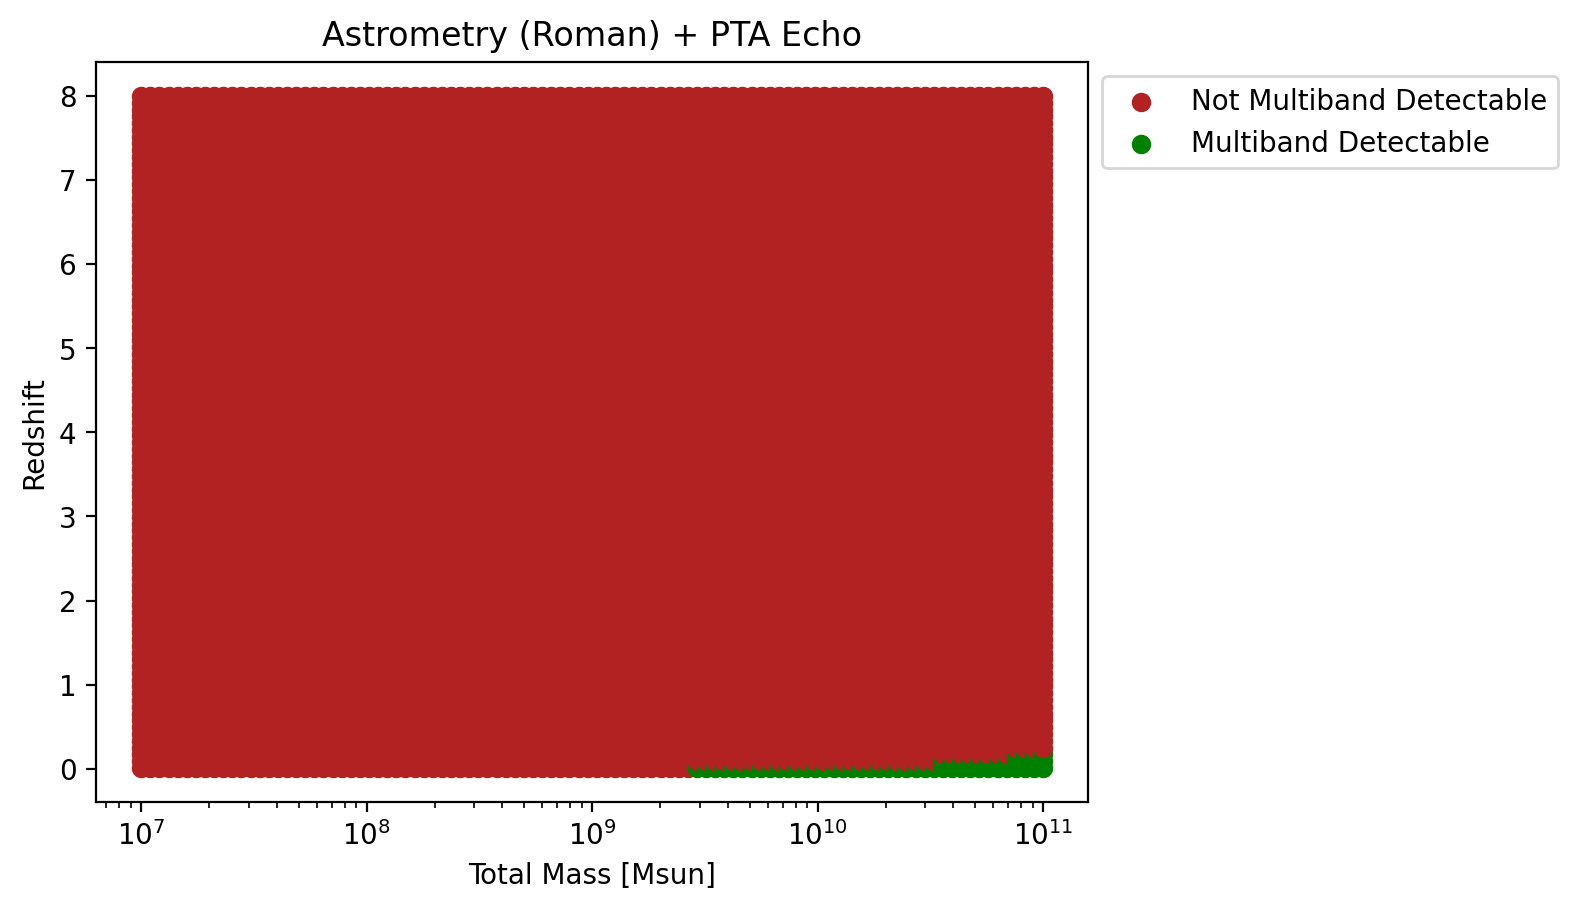

In [124]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [roman.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Astrometry (Roman) + PTA Echo")
plt.show()

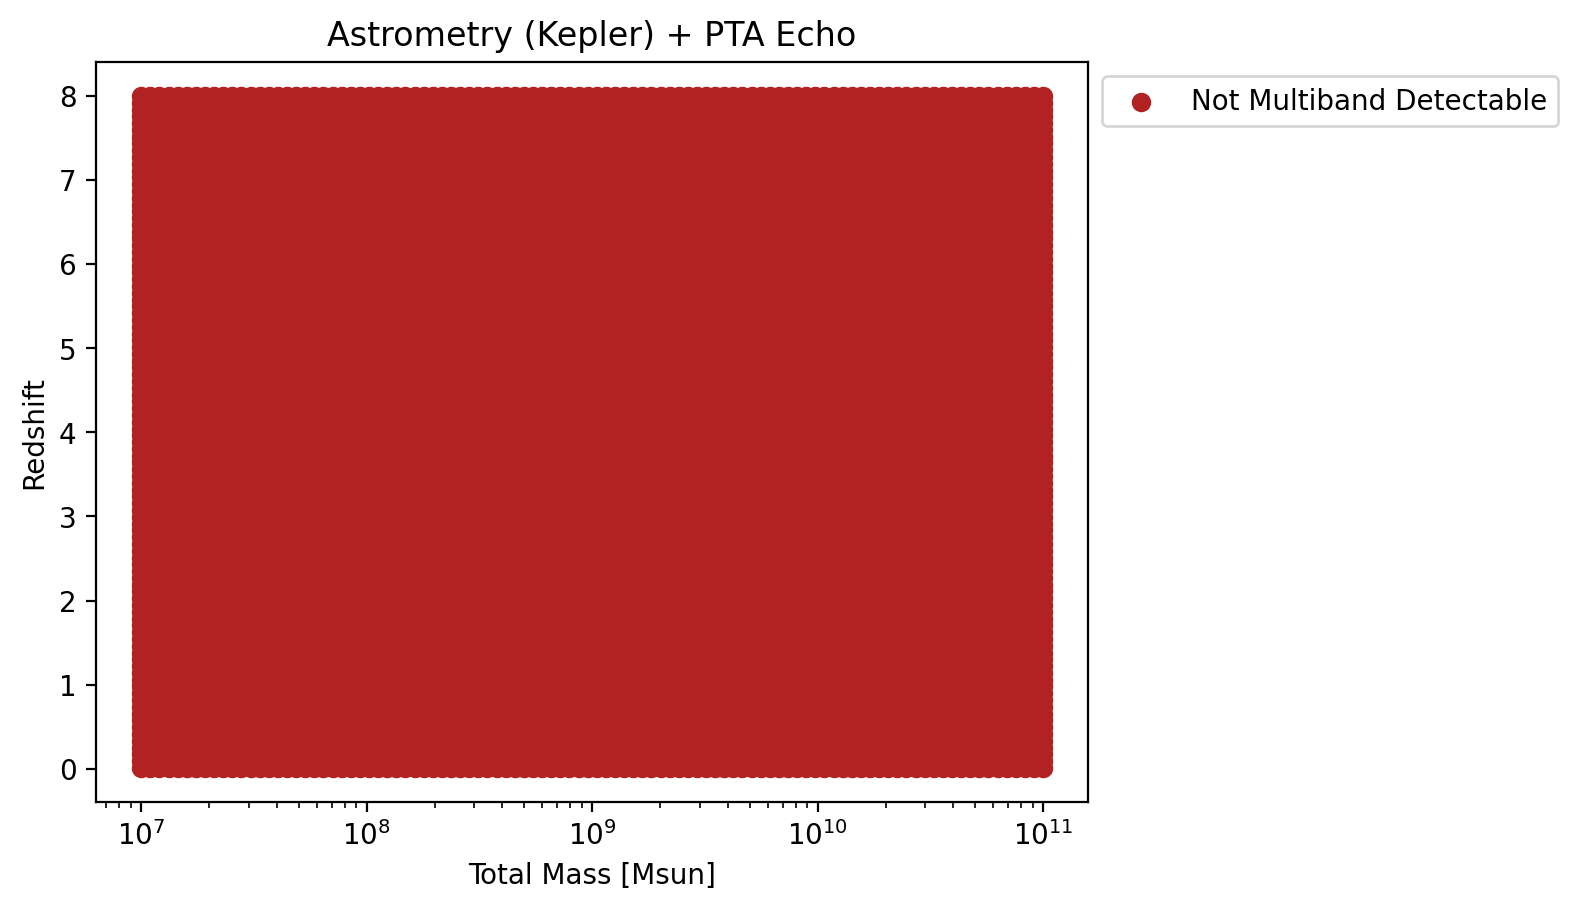

In [125]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [kepler.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Astrometry (Kepler) + PTA Echo")
plt.show()